<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/A9_Redes_CVN_avancadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 9

# Redes Convolucionais Avançadas

### Eduardo Lobo Lustosa Cabral


## 1. Objetivo

Apresentar a classe Funcional do Keras.

Apresentar algumas RNAs de referência muito utilizadas em transferência de aprendizado.

Apresentar convolução 1x1.


### Carregar bibliotecas principais

Em primeiro lugar é necessário importar alguns pacotes do Python que serão usados:
    
- Numpy pacote de cálculo científico com Python
- Matplotlib biblioteca para gerar gráficos em Python
- TensorFlow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.19.0'

## 2. Classe Funcional do Keras

Modelo sequencial do Keras não serve para RNAs que possuem mais do que uma entrada ou uma saída e também para RNAs mais complexas que possuem laços ou estruturas em paralelo.

Para configurar uma RNA com fluxo de informação não sequencial tem que usar a Classe Funcional do Keras (“Functional API”).

A classe Funcional do Keras permite construir RNAs com vários ramos, várias entradas, várias saídas etc.

A classe Funcional do Keras é muito flexível e permite construir praticamente qualquer tipo de RNA.

#### Exemplo de uma RNA configurada com a classe de modelo funcional do Keras

In [2]:
# Importa classe funcional
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Configuração da RNA
X = Input(shape=(32,))
A = Dense(64, activation='relu', name='densa1')(X)
Y = Dense(16, activation='softmax', name='saida')(A)

# Criação da RNA
rna = Model(inputs=X, outputs=Y)

rna.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa1 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,152 (12.31 KB)

 Trainable params: 3,152 (12.31 KB)

 Non-trainable params: 0 (0.00 B)

- Essa RNA inclui todas as camadas necessárias para o cálculo de Y dado X.

#### Comparação entre uma RNA criada com a classe sequencial e a mesma RNA cria com a classe funcional

In [3]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers

# RNA criada com classe sequencial da forma que conhecemos
rna_seq = Sequential()
rna_seq.add(layers.Dense(128, activation='relu',input_shape=(64,)))
rna_seq.add(layers.Dense(32, activation='relu'))
rna_seq.add(layers.Dense(10, activation='softmax'))
rna_seq.summary()
print('\n')

# Mesma RNA criada com classe funcional
x0 = layers.Input(shape=(64,))
x = layers.Dense(128, activation='relu', name='teste')(x0)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)
rna = Model(x0, output)
rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,778 (49.91 KB)

 Trainable params: 12,778 (49.91 KB)

...

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ teste (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,778 (49.91 KB)

 Trainable params: 12,778 (49.91 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Redes de referência

Duas arquiteturas de RNAs convolucionais se tornaram referência na área de visão computacional pelas suas ideias inovadoras e desempenhos extraordinários:

- **RNAs residuais (“Residual networks”)**;


- **“Inception Networks”**.


Essas RNAs apresentam duas grandes inovações:

- Caminhos alternativos do fluxo de informações (ResNet);


- Convolução 1x1 (Inception).

Essas são as RNAs com maior número de camadas que existem.

## 4. Rede ResNet

Referência: He et al., Deep residual networks for image recognition, 2015.

RNAs muito profundas são difíceis de treinar pelo fato do gradiente diminuir a cada camada da rede durante o processo de propagação para trás.

A ResNet possui um bloco denominado Bloco Residual (“Residual Block”) que consiste de um atalho entre duas camadas da rede não vizinhas.

O bloco residual permite treinar de forma mais fácil RNAs muito profundas.


### 4.1 Esquema de um bloco residual:
    
- As ativações da $l$-ésima camada, $\mathbf{a}^{[l]}$, servem como entradas da camada $l+1$ e também da camada $l+2$;


- As ativações $\mathbf{a}^{[l]}$ se somam às ativações $\mathbf{a}^{[l+1]}$ e ambas se tornam entradas da camada $l+2$.


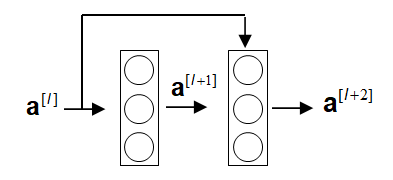

("Bloco_residual1.png")

Nesse bloco existe o caminho padrão e o atalho que é somado ao caminho padrão.


### 4.2 Equações do bloco residual:

$$ \mathbf{z}^{[l+1]} = \mathbf{W}^{[l+1]}\mathbf{a}^{[l]} + \mathbf{b}^{[l+1]}$$

$$\mathbf{a}^{[l+1]} = g^{[l+1]}(\mathbf{z}^{[l+1]})$$

$$ \mathbf{z}^{[l+2]} = \mathbf{W}^{[l+2]}\mathbf{a}^{[l+1]} + \mathbf{b}^{[l+2]}$$

$$\mathbf{a}^{[l+2]} = g^{[l+2]}(\mathbf{z}^{[l+2]} + \mathbf{a}^{[l]})$$


Observe que $\mathbf{z}^{[l+2]}$ tem que ter a mesma dimensão de $\mathbf{a}^{[l]}$.

### 4.3 Rede residual

Uma RNA residual é criada com blocos residuais.

- Esquema de uma RNA convencional:

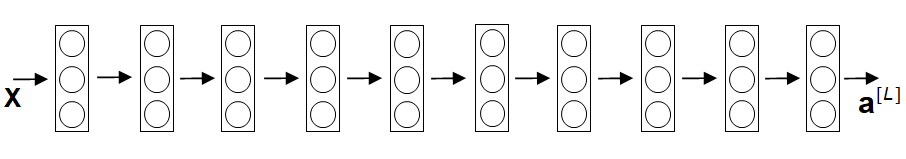

("Rede_convencional.png")

- Adiciona-se os atalhos na RNA convencional e tem-se a RNA residual:



("Rede_residual.png")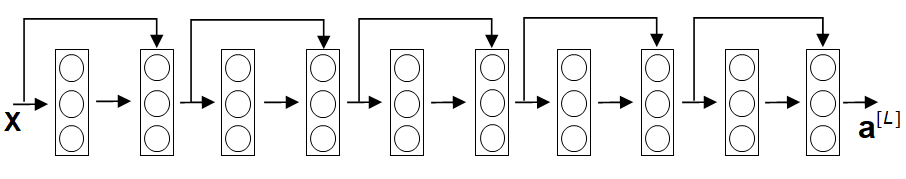

### 4.3 Treinamento

Quanto mais profunda é uma RNA mais difícil de ser treinada.

- O erro de treinamento de uma RNA varia em função do número de camadas da rede.




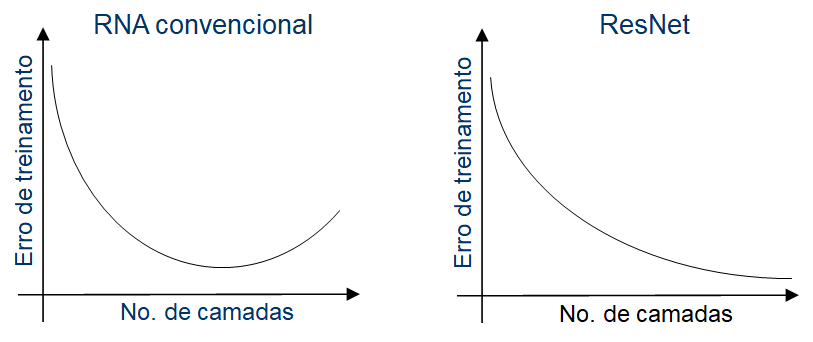

("Treinamento_rede_residual.png")

Na RNA convencional o erro diminui e depois aumenta com o aumento do número de camadas.

Na RNA residual o erro somente diminui com o aumento do número de camadas.

Uma RNA residual pode ter 1.000 ou mais camadas que não tem problema de treinamento.

Porém existe um limite onde o aumento do número de camadas não diminui mais o erro, ou seja, o erro se estabiliza em função do número de camadas quando esse número é muito grande.


#### Porque o treinamento de uma RNA residual funciona muito bem?

- As equações da saída do bloco podem ser escritas como sendo:


$$\mathbf{a}^{[l+2]} = g^{[l+2]}(\mathbf{z}^{[l+2]} + \mathbf{a}^{[l]})$$

$$\mathbf{a}^{[l+2]} = g^{[l+2]}(\mathbf{W}^{[l+2]}\mathbf{a}^{[l+1]} + \mathbf{b}^{[l+2]} + \mathbf{a}^{[l]})$$



- Considerando que todas as camadas do bloco residual tem função de ativação ReLu, então, se $\mathbf{W}^{[l+2]} = \mathbf{b}^{[l+2]} = 0$, temos que:

$$\mathbf{a}^{[l+2]} = \mathbf{a}^{[l]}$$


- Ou seja, se nada foi aprendido a mais na camada $l+2$, então a saída calcula pelo bloco residual é uma função identidade.


Imagine que adicionamos um bloco residual na última camada de uma RNA.

Como a função identidade é fácil de aprender pelo bloco residual, temos a seguinte situação:

- Adicionar um bloco residual na última camada de uma RNA não altera muito essa RNA, porque a função identidade é facilmente aprendida pelo bloco residual;


- O pior que pode acontecer é o bloco residual não fazer nada e calcular a função identidade;


- Blocos residuais sempre aprendem alguma informação que melhora um pouco o desempenho da RNA, assim, adicionar vários blocos residuais pode resultar em uma grande melhoria da RNA.


<font color='red'>$\to$ Ressalta-se que é muito difícil treinar uma RNA muito profunda sem blocos residuais.</font>

### 4.4 Restrição

Existe uma restrição grande nos blocos residuais:

- $\mathbf{a}^{[l+2]}$ tem que ter a mesma dimensão de $\mathbf{a}^{[l]}$.


- Isso implica em princípio no uso de operações de convolução que preservam as dimensões (“same convolution”).


De fato essa restrição pode ser eliminada alterando as equações do bloco de forma a adicionar uma matriz extra de pesos para ajustar a dimensão:

$$\mathbf{a}^{[l+2]} = g^{[l+2]}(\mathbf{W}^{[l+2]}\mathbf{a}^{[l+1]} + \mathbf{b}^{[l+2]} + \mathbf{W_s} \mathbf{a}^{[l]})$$

- onde $\mathbf{W_s}$ é uma matriz de pesos para ajuste de dimensões $\to$ adiciona mais parâmetros que devem ser treinados.


- Por exemplo se dimensão de $\mathbf{a}^{[l]}$ é 256 e de $\mathbf{a}^{[l+2]}$ é 128, então a dimensão de $\mathbf{W_s}$ é 128x256.


### 4.5 Arquitetura da ResNet de He et al., Deep residual networks for image recognition, 2015:


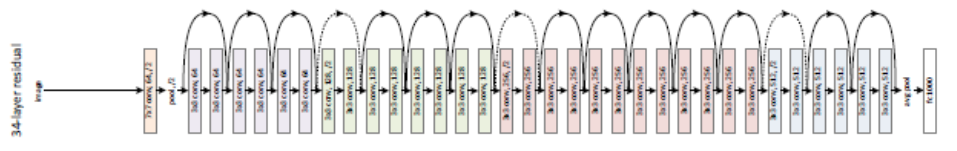
("ResNet.png")

### 4.6  Configuração de rede Residual no Keras

Na medida em que numa rede residual os blocos residuais se repetem é interessante definir uma função para criar um bloco residual para evitar repetição de comandos.

A Figura abaixo apresenta um blobo residual.

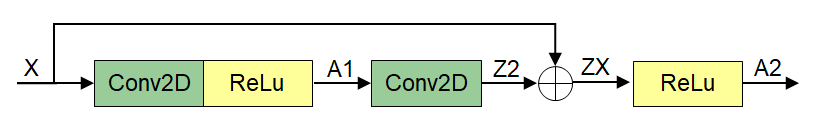

("Bloco_residual.png")

In [4]:
# Define função para criar bloco residual
def bloco_residual(X,n):

    # Entradas: X -> tensor de entrada
    #           n -> número de filtros
    # Saída: A2 -> tensor de saída

    A1 = layers.Conv2D(n, (3,3), strides=1, padding='same', activation='relu')(X)
    Z2 = layers.Conv2D(n, (3,3), strides=1, padding='same', activation='linear')(A1)

    # Adiciona os dois ramos
    ZX = layers.Add()([Z2, X])
    A2 = layers.Activation('relu')(ZX)

    # Retorna saída
    return A2

Utilizando a função que cria um bloco residual, vamos criar uma RNA com 2 blocos residuais seguidos de uma camada softmax com 10 classes.

Quando o número de canais de um bloco reisudal é diferente do número de canais do bloco anterior, entre os dois blocos residuais deve ser colocada pelo menos uma camada convolucional para ajustar o número de canais.

In [5]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

# Definição da entrada
input_shape = (32, 32, 3)
X0 = layers.Input(shape=input_shape)

# Camada convolucional para ajustar número de canais
X1 = layers.Conv2D(16, (3,3), strides=1, padding='same', activation='relu')(X0)

# Primeiro bloco residual com 16 filtros
X2 = bloco_residual(X1,16)

# Camada convolucional para ajustar número de canais
X3 = layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu')(X2)

# Camada de max-pooling
X4 = layers.MaxPooling2D((2, 2))(X3)

# Segundo bloco residual com 32 filtros
X5 = bloco_residual(X4,32)

# Camada de max-pooling
X6 = layers.MaxPooling2D((2, 2))(X5)

# Camada de Flattening
X7 = layers.Flatten()(X6)

# Camada densa de classificação com 6 classes
Y = layers.Dense(10, activation='softmax')(X7)

# Criação da RNA
rna = Model(X0, Y)

# Mostra resumo da RNA
rna.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      2,320 │ conv2d_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 16)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      4,640 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ conv2d_5[0][0],   │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 32)  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │     20,490 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,714 (190.29 KB)

 Trainable params: 48,714 (190.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Fluxograma da rede residual de dois blocos residuais

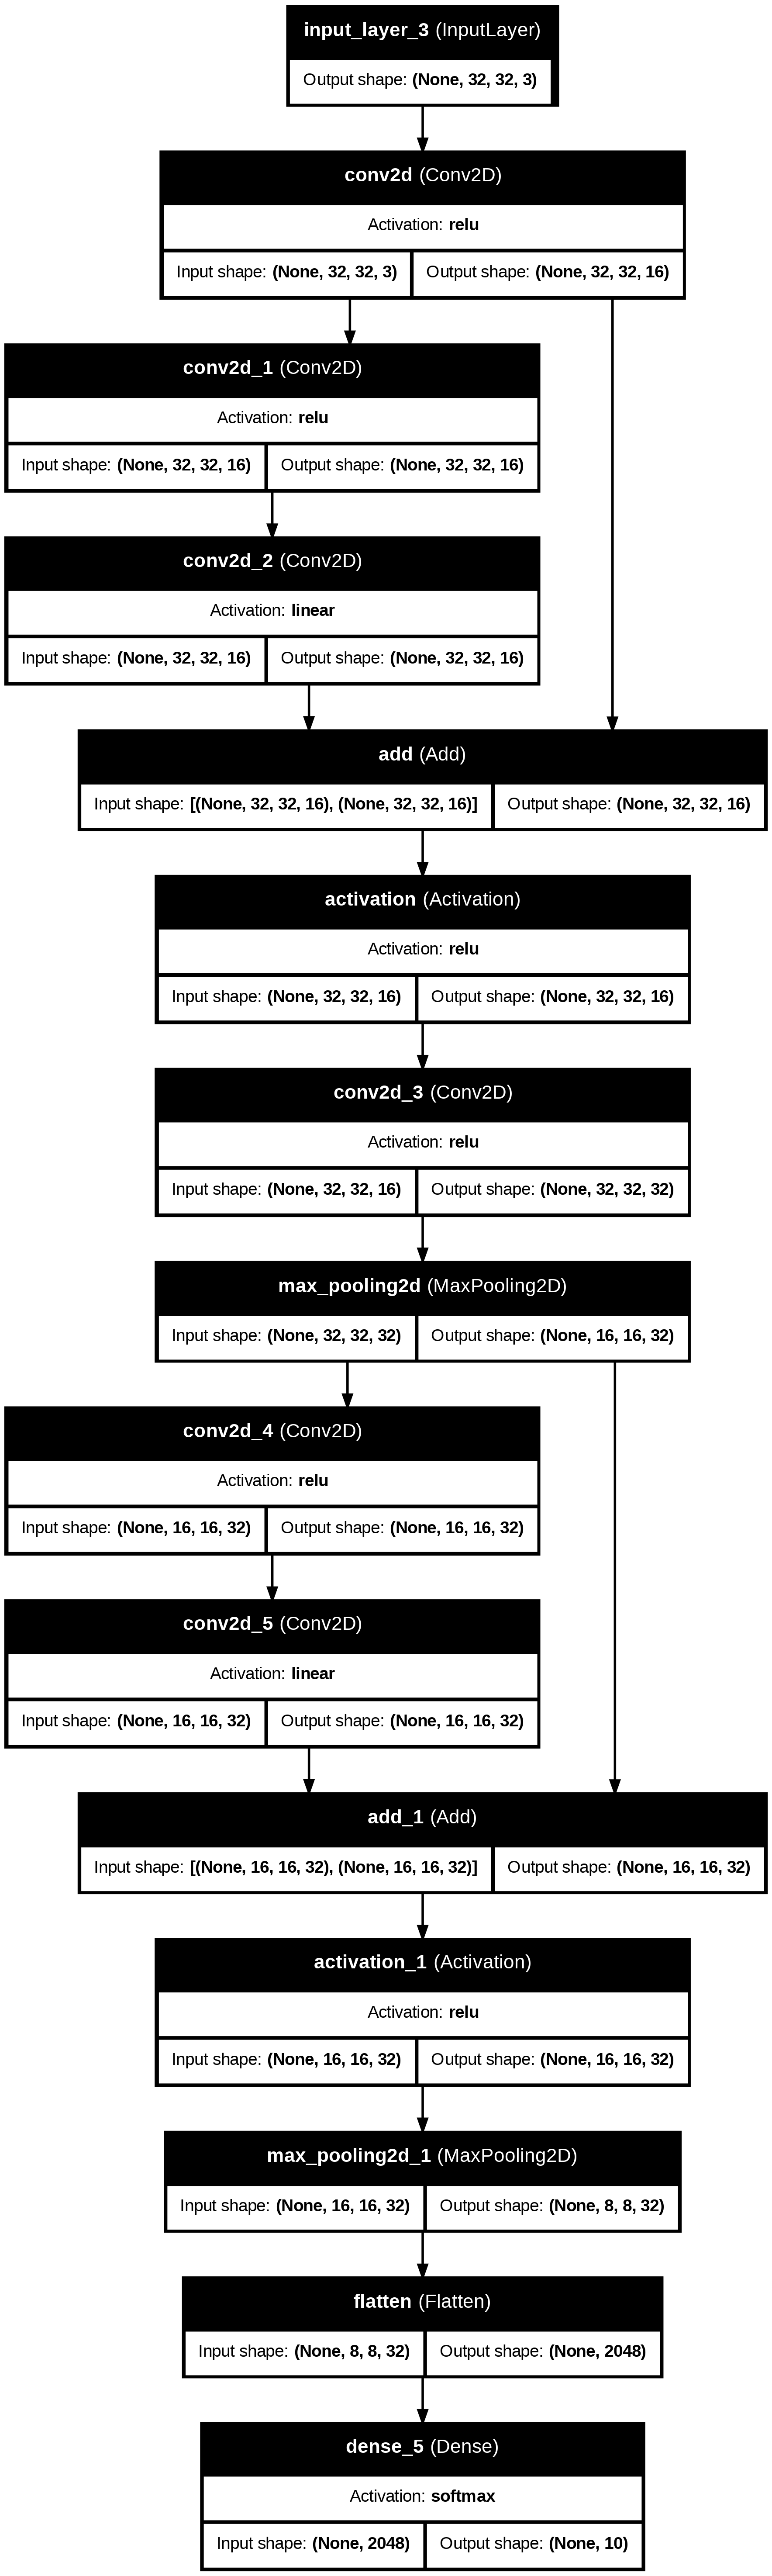

In [6]:
# Cria um gráfico da RNA no arquivo rna.png
plot_model(rna, to_file='rnaRes.png', show_shapes=True, show_layer_names=True, show_layer_activations=True)

## 5. Convolução 1x1

Referência: Lin et al., Network in network, 2013.

Convolução 1x1 representa realizar a operação de convolução de uma imagem por um filtro de dimensão 1x1.

#### Se tivermos um tensor de um único canal:


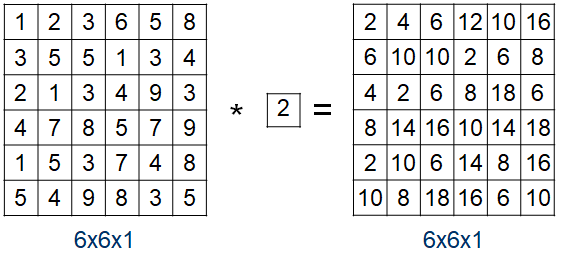
("Conv1x1_0.png")

$\to$ Essa operação consiste simplesmente de uma multiplicação por uma constante.

#### Se tivermos um tensor de mais de um canal:

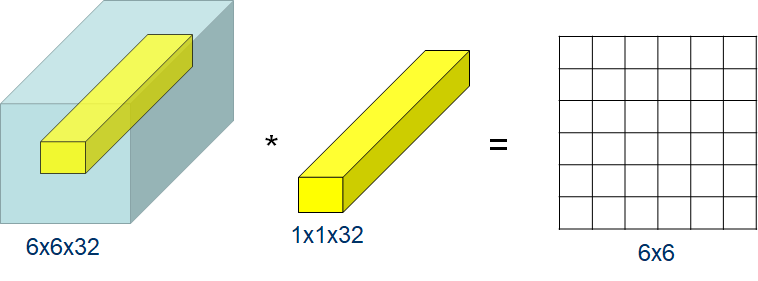

("Conv1x1_1.png")

$\to$ Essa operação consiste do cálculo da média ponderada dos pixels de todos os canais, onde os pesos são os parâmetros do filtro.

### 5.1  Camada convolucional com filtros de dimensão 1x1

Na camada convolucional com filtros 1x1, após a multiplicação dos pesos dos filtros pelos valores do tensor em todos os canais, soma uma constante (viés) e aplica uma função de ativação.

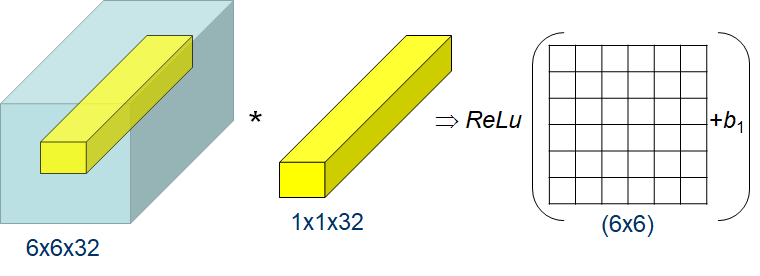

("Conv1x1_2.png")

$\to$ Pode imaginar que essa operação consiste de um neurônio que recebe 32 entradas, multiplica por pesos, soma um viés e aplica uma função de ativação.

Se existirem vários filtros 1x1, então, o resultado da camada será um tensor com largura e altura iguais ao tensor original e número de canais igual ao número de filtros.

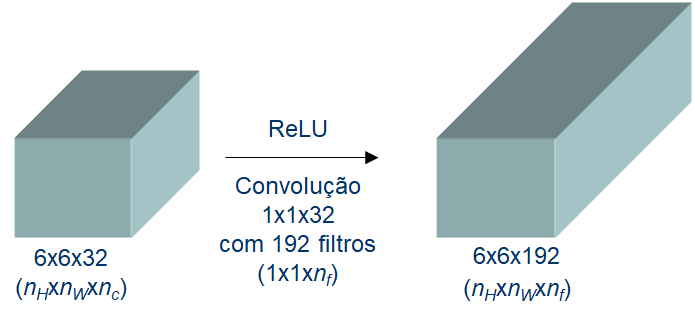

("Conv1x1_3.png")

$\to$ Convolução 1x1 preserva largura e altura.

Camada convolucional com filtro 1x1 aplica um cálculo não trivial $\to$ age como se fosse uma camada densa.

Como tem-se uma “camada densa” aplicada em cada elemento da largura e altura do tensor, então, essa operação também é chamada rede dentro de rede.

Utilidade da convolução com filtro 1x1:

- Forma eficiente para diminuir número de canais quando se torna muito grande;


- Muito eficiente para detectar novas características;


**Convolução 1x1 é usada nas RNAs Inceptions.**

## 6. Rede Inception

Referência: Szegedy et al., Going deeper with convolutions, 2014.

Uma RNA Inception possui na mesma camada filtros com dimensões diferentes e tipo de operações diferentes.

No lugar de escolher uma única operação por camada pode-se incluir várias operações diferentes.

### 6.1 Módulo inception

**Exemplo de uma camada com várias operações:**

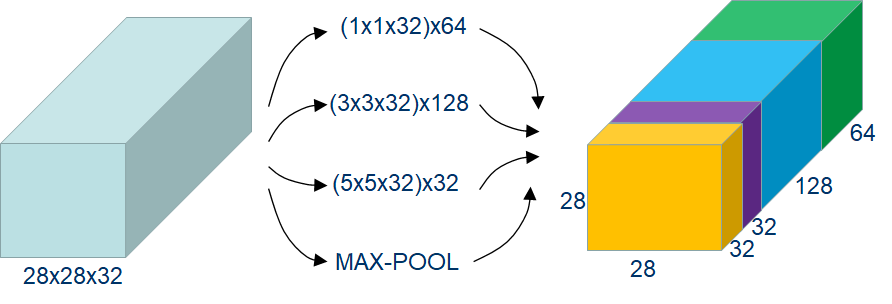

("Inception_1.png")


- Largura e altura das saídas de todas operações precisam ser iguais;


- Todas operações de convolução são do tipo “same” com stride igual a 1;


- Resultados são empilhados na saída;


- No. de canais na saída é a soma do no. de canais de cada operação (256).

**Exemplo de um módulo de uma RNA Inception:**

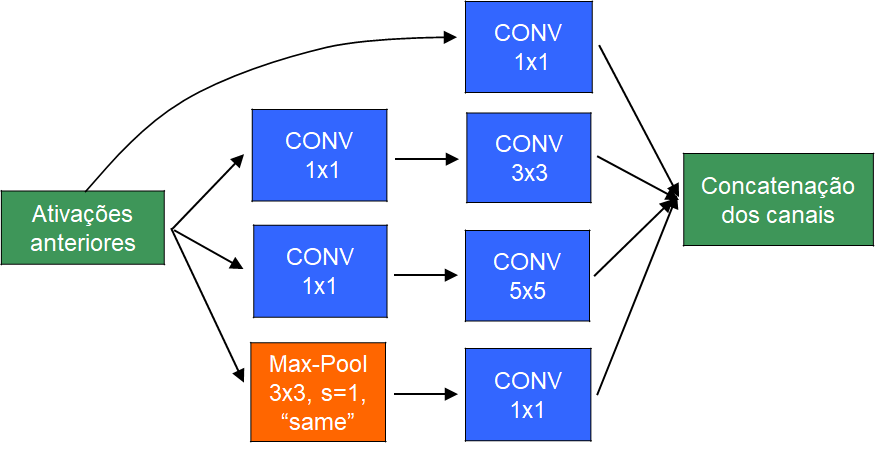

("Inception_2.png")


Existem diferentes tipos de módulos inception, mas o conceito geral é o mesmo.

### 6.2 RNA Inception

**Módulo de uma RNA Inception:**

- Vários tipos de filtros e operações no módulo;


- Os resultados de todos os filtros tem a mesma largura e mesma altura;


- Operação max-pooling é usada com stride s = 1, e padding p diferente de zero para preservar largura e altura da saída.


**RNA Inception:**

- Composta por vários módulos inceptions;


- Repete os módulos inceptions várias vezes com pequenas modificações;


- Possui saídas parciais, cuja função é auxiliar na prevenção de problemas de overfitting (uma forma de regularização).  


### 6.3 Diagrama da RNA Inception de "Szegedy et al., Going deeper with convolutions, 2014"

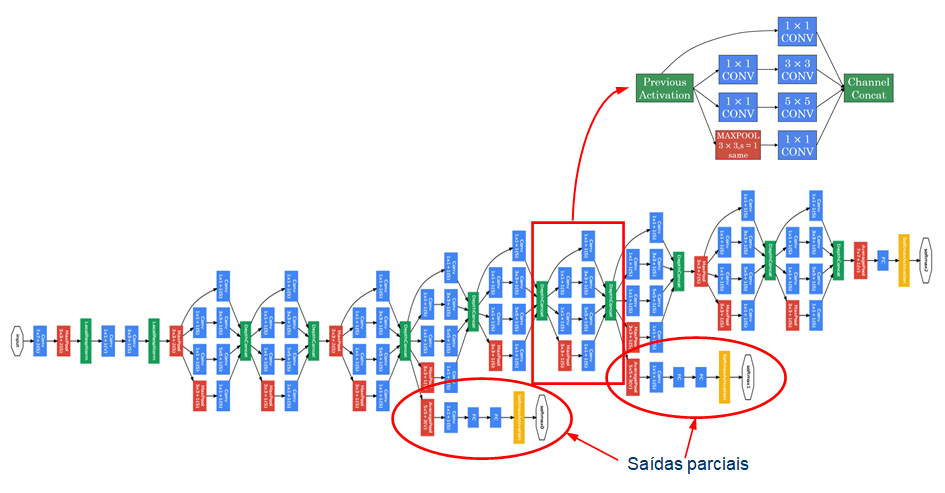

("Inception_3.png")

### 6.4  Configuração de rede Inception no Keras

Na medida em que numa rede inception os blocos inceptions se repetem é interessante definir uma função para criar um bloco inception para evitar repetição de comandos.

A Figura abaixo apresenta um blobo inception.

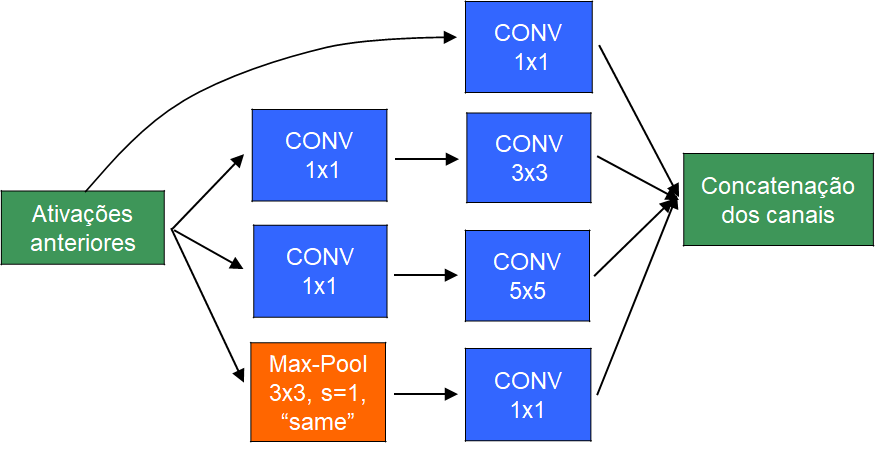

("Inception_2.png")

Configuração de um módulo inception dentro de uma função:

- Adimite que cada filtro possui $n$ canais;


- Todos os strides são iguais a 1 (padrão do keras).

In [7]:
# Difinição de função para criar módulo inception
def modulo_inception(x,n):
    # Define os ramos
    ramo_a = layers.Conv2D(n, (1,1), activation='relu')(x)
    ramo_b = layers.Conv2D(n, (1,1), activation='relu')(x)
    ramo_b = layers.Conv2D(n, (3,3), activation='relu', padding='same')(ramo_b)
    ramo_c = layers.Conv2D(n, (1,1), activation='relu')(x)
    ramo_c = layers.Conv2D(n, (5,5), activation='relu', padding='same')(ramo_c)
    ramo_d = layers.MaxPooling2D((3,3), strides=1, padding='same')(x)
    ramo_d = layers.Conv2D(n, (1,1), activation='relu')(ramo_d)

    # Une os ramos na saída do módulo
    y = layers.concatenate([ramo_a, ramo_b, ramo_c, ramo_d], axis=-1)

    # Retorna saída
    return y

Utilizando a função que cria um módulo inception, vamos criar uma RNA com 2 blocos inceptions seguidos de uma camada softmax com 10 classes.

In [8]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Definição da entrada
input_shape = (32, 32, 3)
X = layers.Input(shape=input_shape)

# Primeiro bloco inception com filtros de 64 canais
X1 = modulo_inception(X,64)

# Camada de pooling entre os módulos
X2 = layers.MaxPooling2D((3,3), strides=2)(X1)

# Segundo modulo inception com filtros de 128 canais
X3 = modulo_inception(X2,128)

# Camada de pooling entre os módulos
X4 = layers.MaxPooling2D(2,2)(X3)

# Camada de Flattening
X5 = layers.Flatten()(X4)

# Camada densa de classificação com 6 classes
Y = layers.Dense(10, activation='softmax')(X5)

# Criação da RNA
rna = Model(X, Y)

# Mostra resumo da RNA
rna.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │        256 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │        256 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32, 3) │          0 │ input_layer_4[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        256 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_7[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    102,464 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │        256 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_8[0][0],   │
│                     │                   │            │ conv2d_10[0][0],  │
│                     │                   │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 15, 15,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 15, 15,    │     32,896 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 15, 15,    │     32,896 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 15, 15,    │          0 │ max_pooling2d_3[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 15, 15,    │     32,896 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 15, 15,    │    147,584 │ conv2d_13[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 15, 15,    │    409,728 │ conv2d_15[0][0]   │
│                     │ 128)              │            │                 

 Total params: 1,080,202 (4.12 MB)

 Trainable params: 1,080,202 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

#### Fluxograma da rede inception de dois bloco

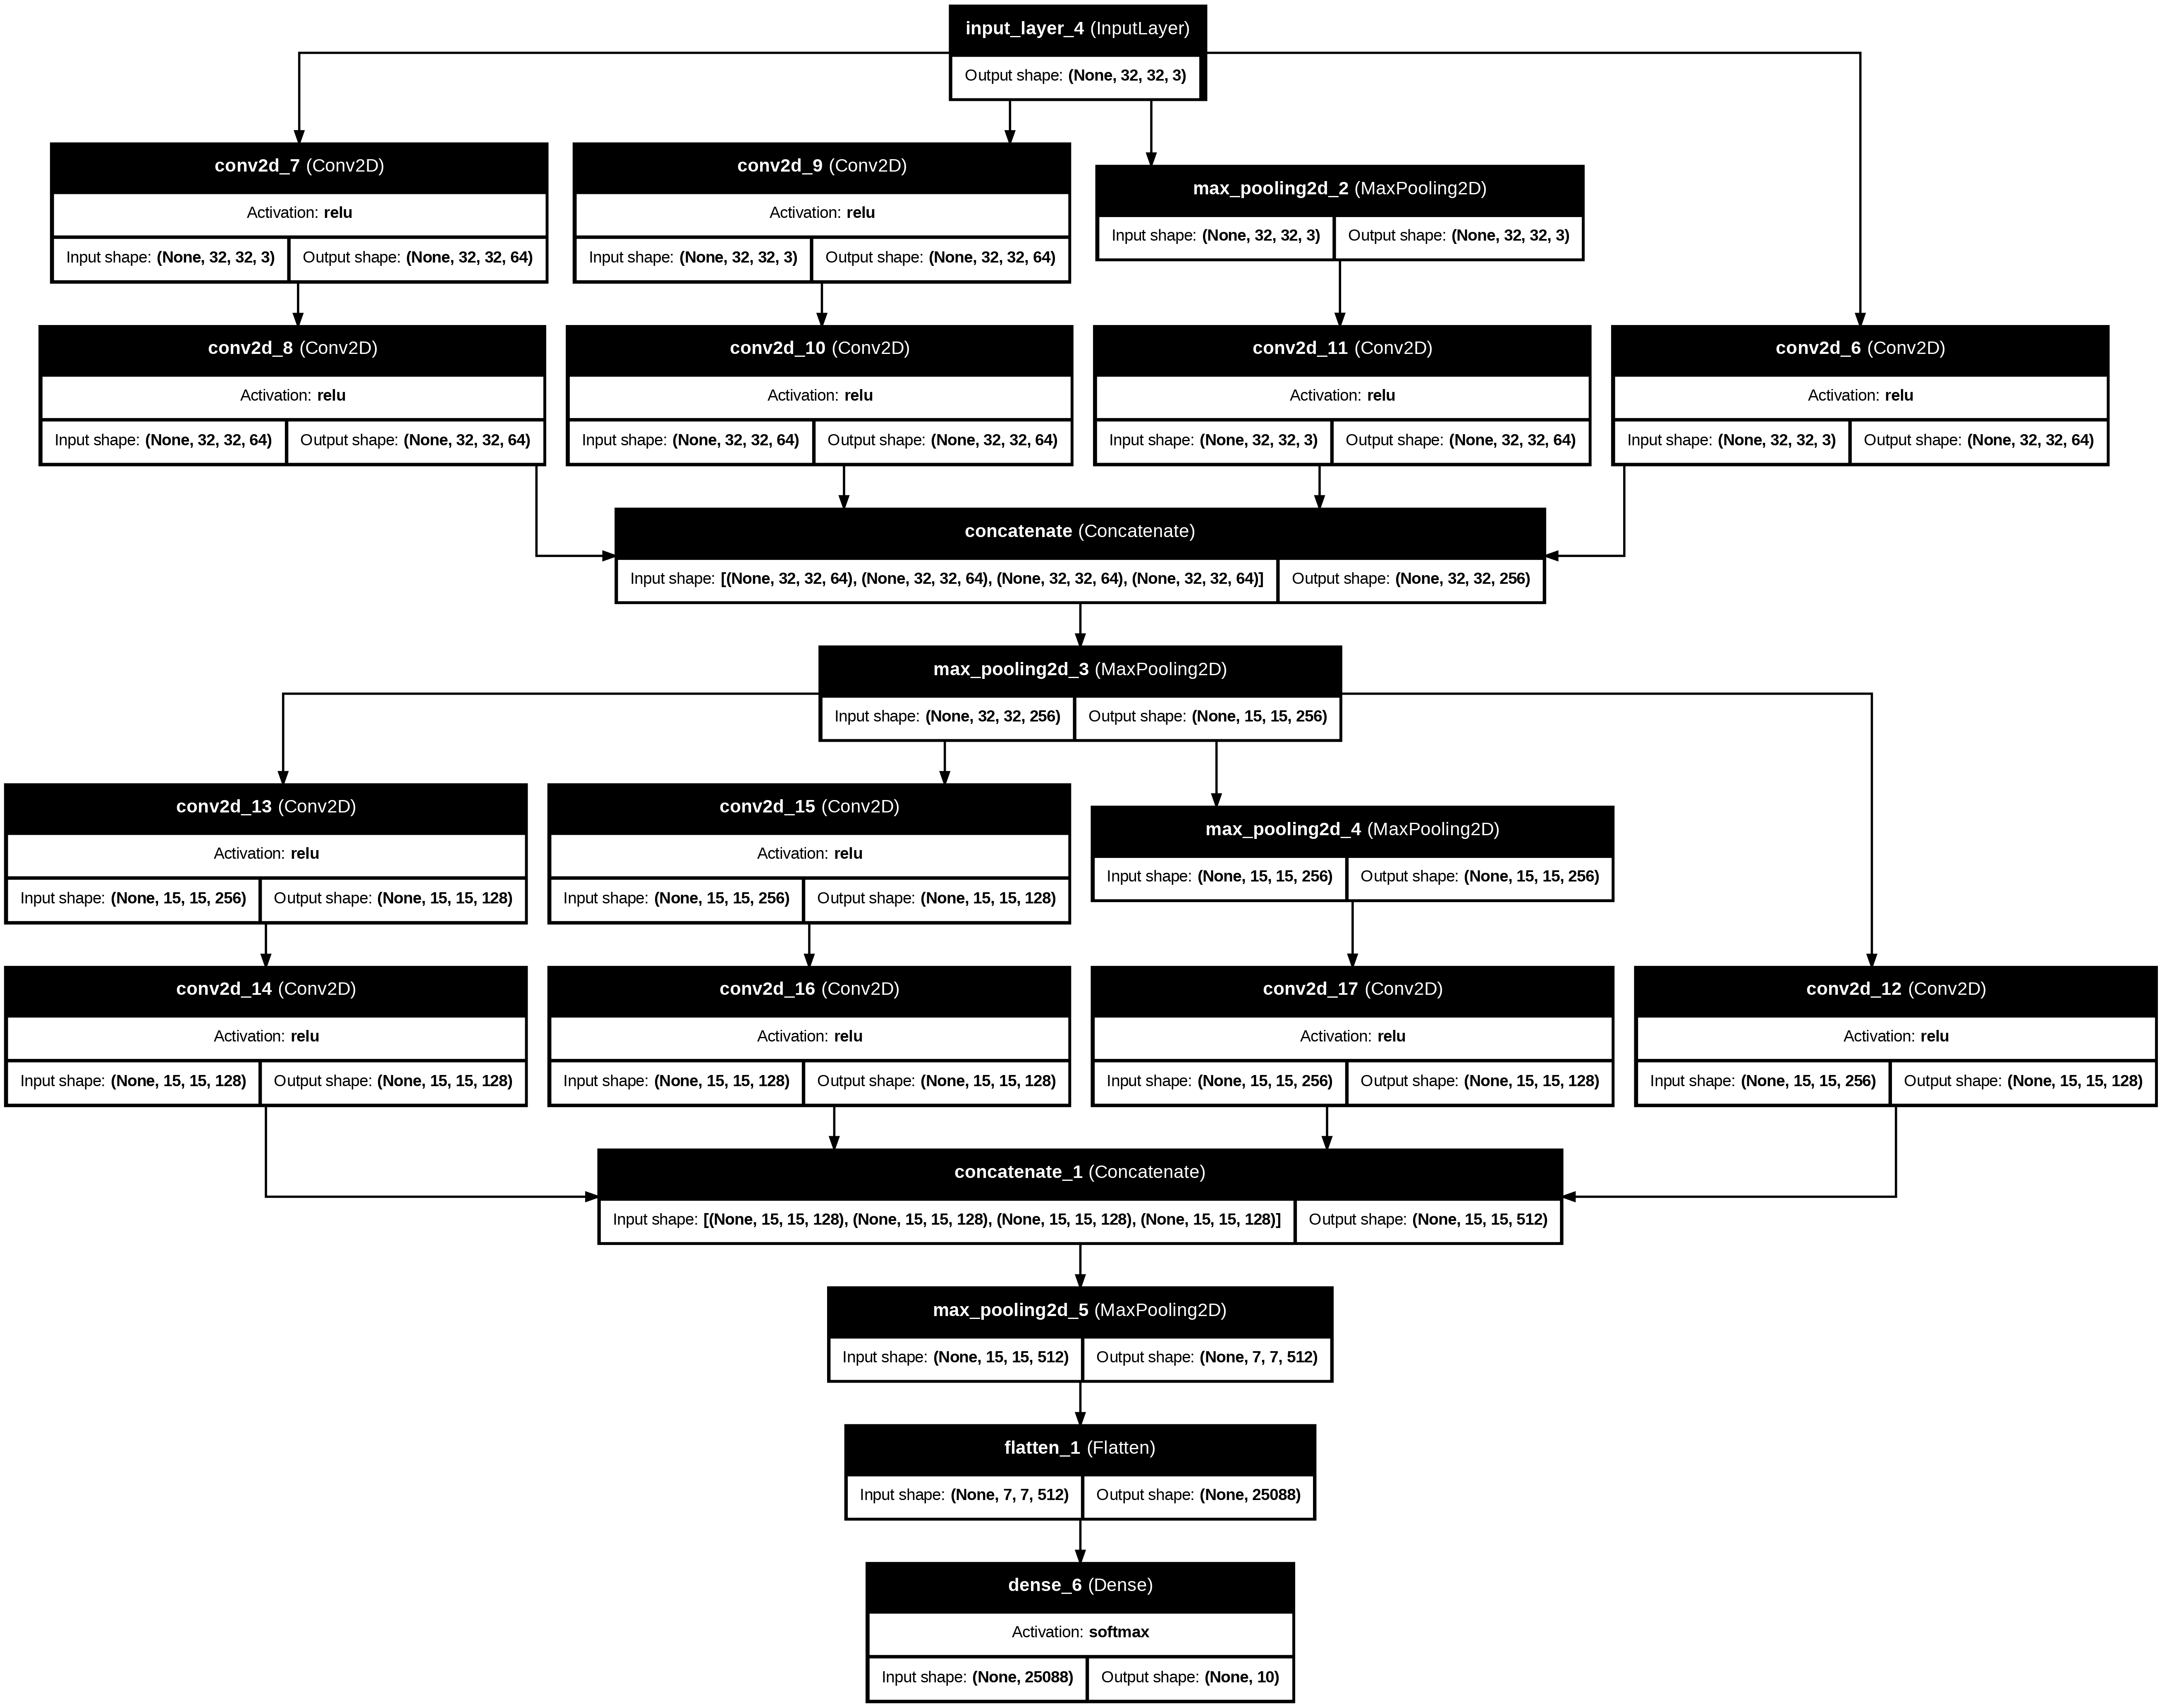

In [9]:
# Cria um gráfico da RNA no arquivo rna.png
plot_model(rna, to_file='rna_inception.png', show_shapes=True, show_layer_names=True, show_layer_activations=True)

## 7. Exemplo de uso da rede inception

Conjunto de dados TFFlowres.

As classes de flores estão descritas por números inteiros, codificadas da seguinte forma:

- "dente de leão": 0
- "margarida": 1
- "tulipa": 2
- "girassol": 3
- "rosa": 4

Para usar as classes descritas por números inteiros, sem a necessidade de transformar em vetores "one-hot", temos que usar a função de custo `sparse_categorical_crossentropy`, que realiza essa transformação internamente de forma automática.

In [10]:
import tensorflow_datasets as tfds

In [11]:
train_data, test_data = tfds.load('TFFlowers', shuffle_files=True, split=['train[:80%]', 'train[-20%:]'], as_supervised=True, with_info=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.IOSWYU_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [12]:
print('Número exemplos de treinamento =', len(list(train_data)))
print('Número exemplos de teste =', len(list(test_data)))

Número exemplos de treinamento = 2936
Número exemplos de teste = 734


Classe: 2


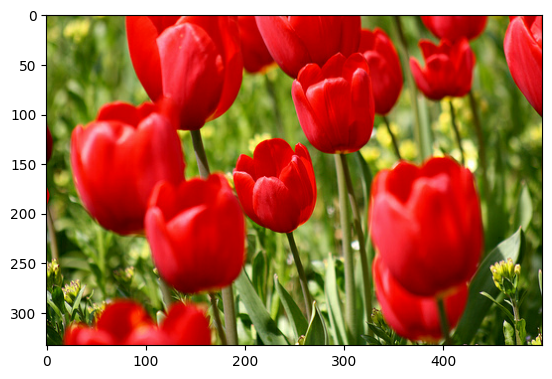

Classe: 3


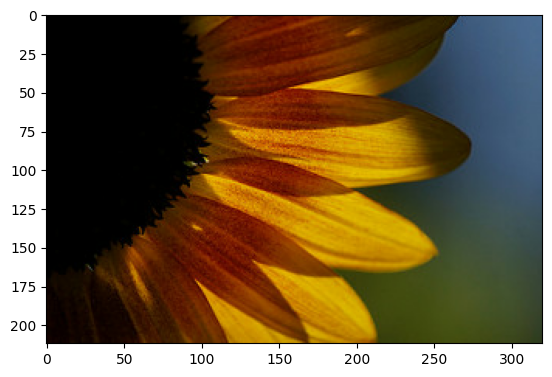

Classe: 3


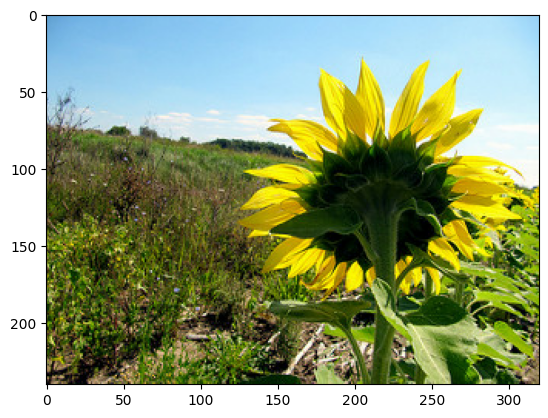

In [13]:
# Itera no conjutno de dados pegando exemplos
for data in train_data.take(3):
    image, label = data

    print("Classe: {}".format(label))
    plt.imshow(image)
    plt.show()

In [14]:
# Dimensão das imagens usadas pela MobiliNet
IMAGE_SIZE = (64, 64)

# Função usada para redimensionar e normalizar as imagens
def format_image(image, label):
    image = tf.cast(image, dtype=tf.float32)
    image = tf.image.resize(image, IMAGE_SIZE)/255.
    label = tf.cast(label, tf.int32)
    return  image, {'saida1': label, 'saida2': label}

# Define tamanho do lote de dados de treinamento e validação
BATCH_SIZE = 128

# Cria lotes de dados usando o método map() para chamar a função format_image()
train_batches = train_data.map(format_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
test_batches = test_data.map(format_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

In [15]:
for img, lb in train_batches.take(1):
    print('Dimensão de um lote de imagens:', img.shape)
    print('Dimensão de um lote da saídas:', lb['saida1'].shape)
    print('Dimensão de um lote da saídas:', lb['saida2'].shape)

Dimensão de um lote de imagens: (128, 64, 64, 3)
Dimensão de um lote da saídas: (128,)
Dimensão de um lote da saídas: (128,)


In [16]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Definição da entrada
input_shape = (64, 64, 3)
X = layers.Input(shape=input_shape)

# Primeiro bloco inception com filtros de 16 canais
X1 = modulo_inception(X,16)

# Camada de pooling entre os módulos
X2 = layers.MaxPooling2D(3, strides=2)(X1)

# Primeira saída - Camada densa de classificação com 5 classes
XY1 = layers.Flatten()(X2)
Y1 = layers.Dense(5, activation='softmax', name='saida1')(XY1)

# Segundo modulo inception com filtros de 32 canais
X3 = modulo_inception(X2,32)

# Camada de pooling entre os módulos
X4 = layers.MaxPooling2D(2,2)(X3)

# Camada de Flattening
X5 = layers.Flatten()(X4)

# Camada densa de classificação com 6 classes
Y2 = layers.Dense(5, activation='softmax', name='saida2')(X5)

# Criação da RNA
rna = Model(inputs=X, outputs=[Y1, Y2])

# Mostra resumo da RNA
rna.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │         64 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │         64 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64, 3) │          0 │ input_layer_5[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │         64 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │      2,320 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │      6,416 │ conv2d_21[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │         64 │ max_pooling2d_6[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_18[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_20[0][0],  │
│                     │                   │            │ conv2d_22[0][0],  │
│                     │                   │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 31, 31,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 31, 31,    │      2,080 │ max_pooling2d_7[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 31, 31,    │      2,080 │ max_pooling2d_7[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 31, 31,    │          0 │ max_pooling2d_7[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 31, 31,    │      2,080 │ max_pooling2d_7[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 31, 31,    │      9,248 │ conv2d_25[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 31, 31,    │     25,632 │ conv2d_27[0][0]   │
│                     │ 32)               │            │                 

 Total params: 503,722 (1.92 MB)

 Trainable params: 503,722 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

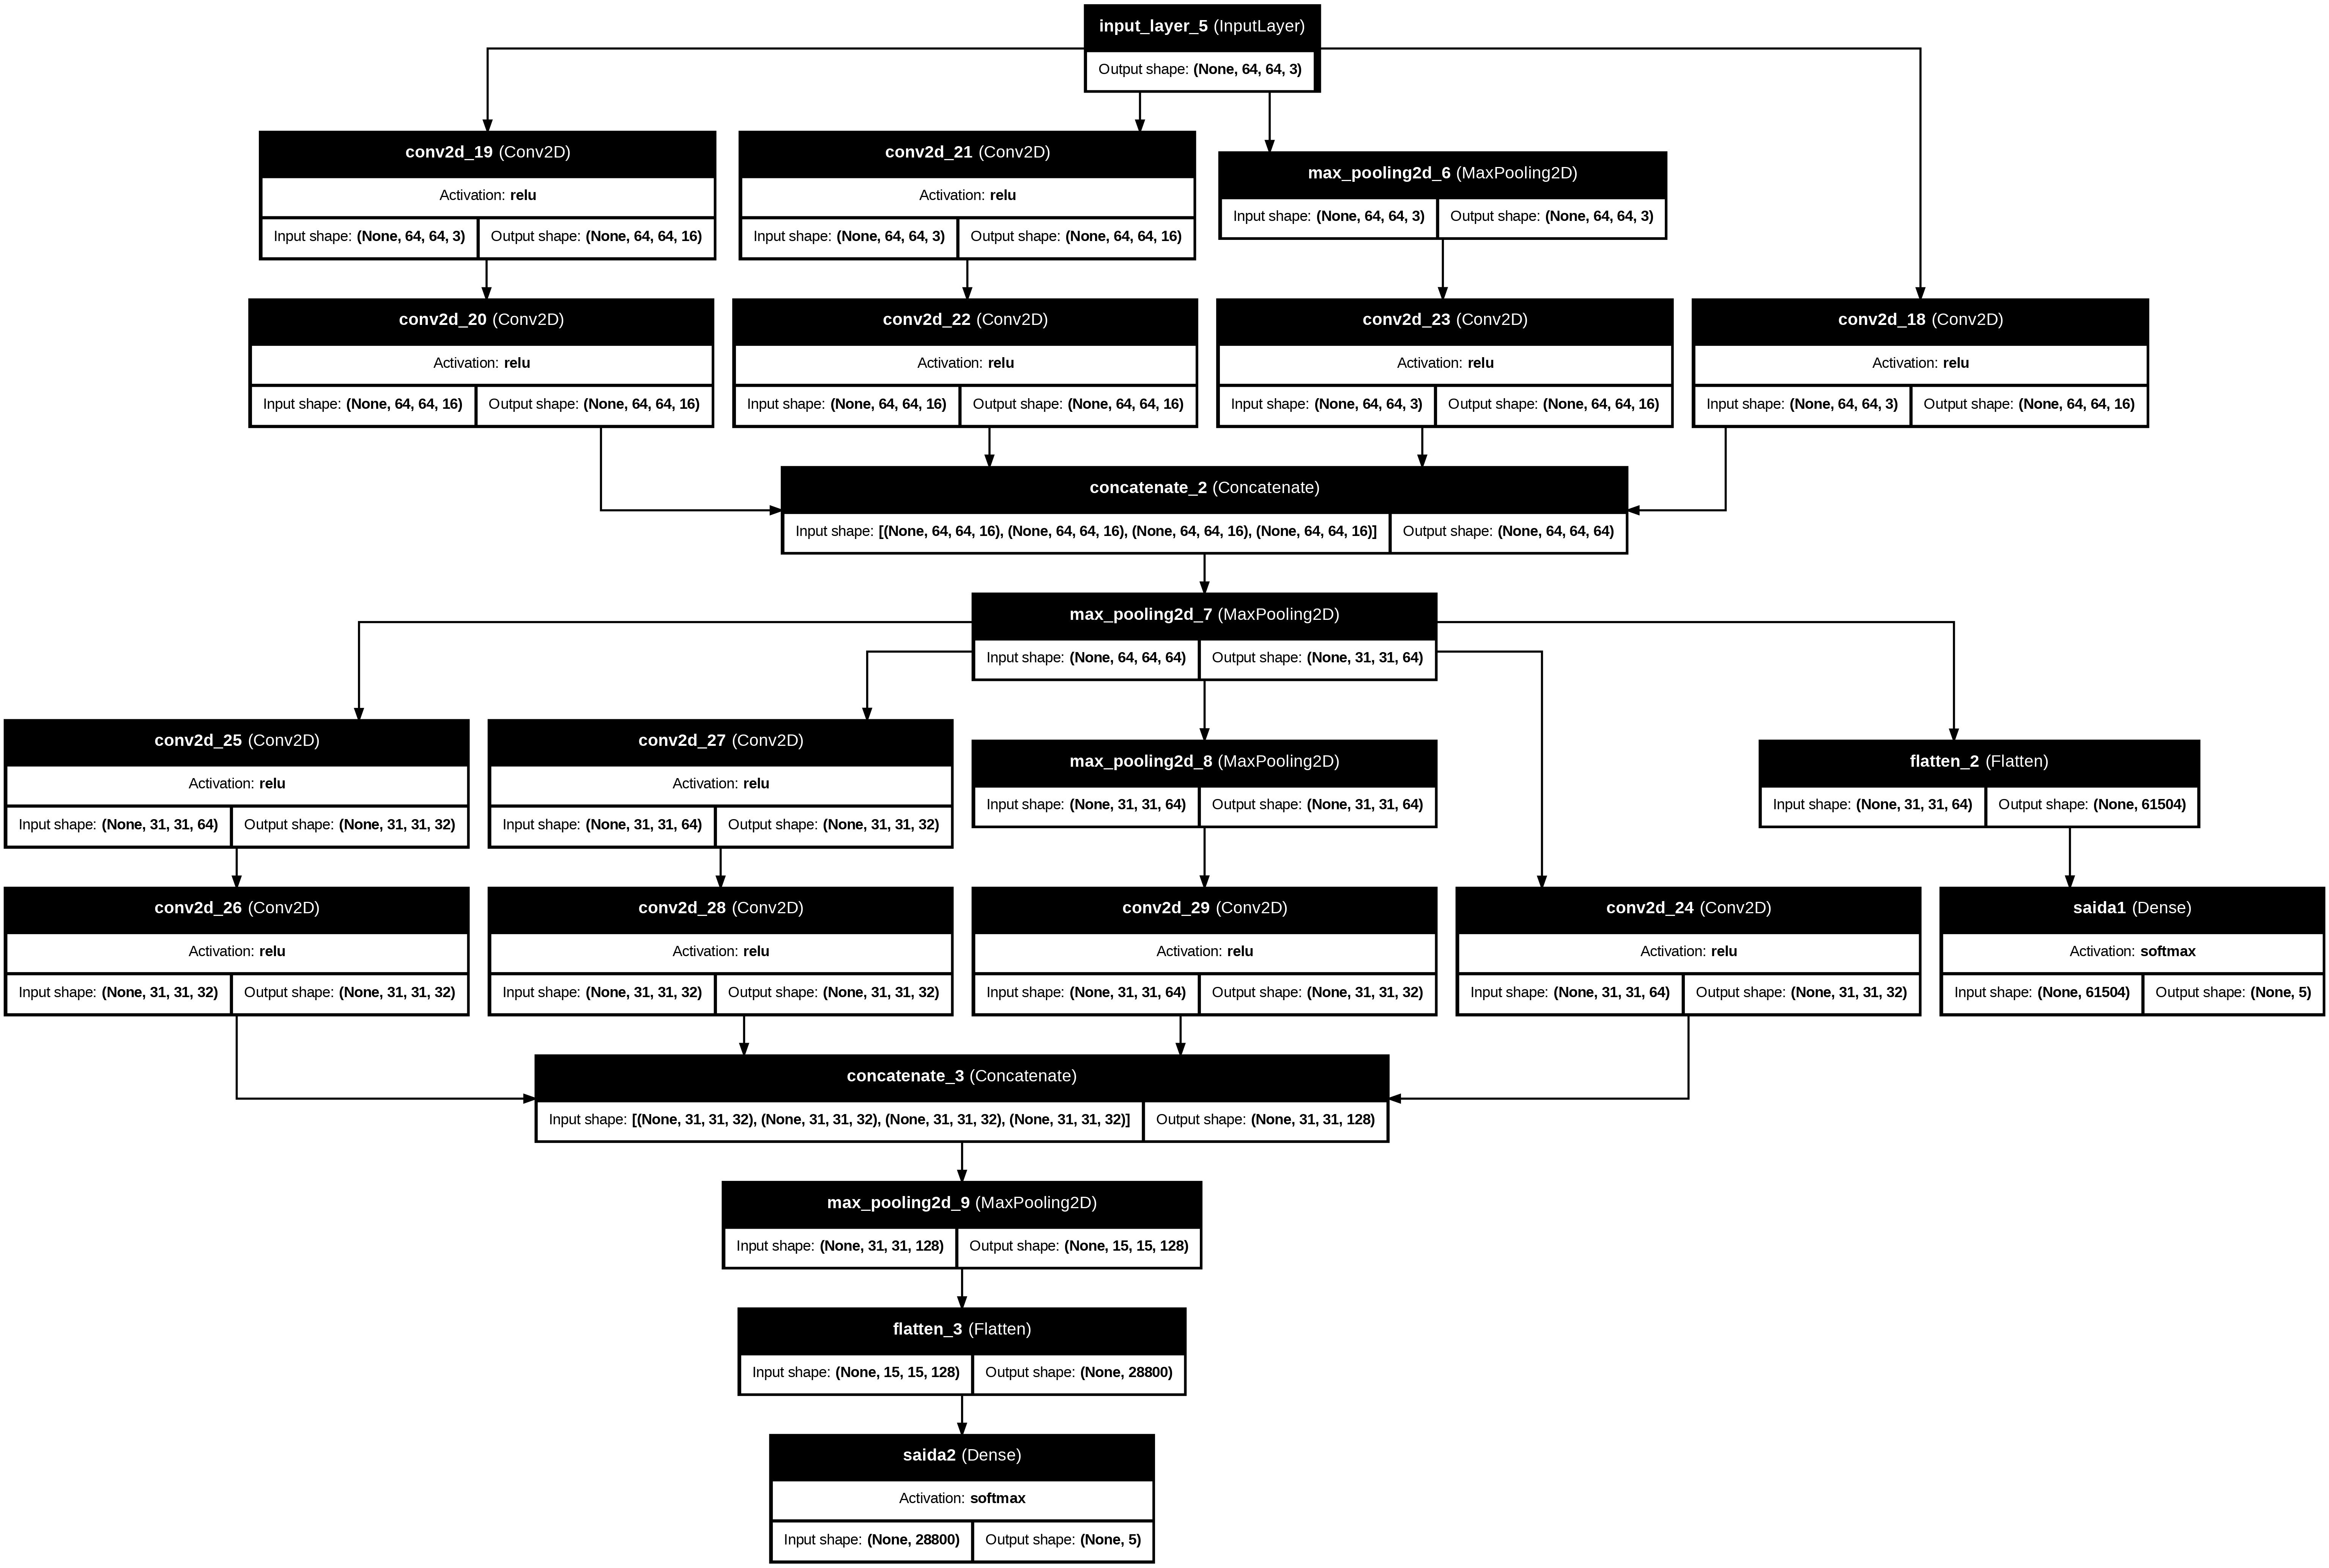

In [17]:
# Cria um gráfico da RNA no arquivo rna.png
plot_model(rna, show_shapes=True, show_layer_names=True, show_layer_activations=True)

In [18]:
# importa do keras a classe dos otimizadores
from tensorflow.keras import optimizers

# Configuração do otimizador
adam = optimizers.Adam(learning_rate=0.001)

rna.compile(optimizer=adam,
            loss={
                  'saida1': 'sparse_categorical_crossentropy',
                  'saida2': 'sparse_categorical_crossentropy'},
            loss_weights={
                  'saida1': 1.0,
                  'saida2': 1.0},
            metrics={
                  'saida1': 'accuracy',
                  'saida2': 'accuracy'})

In [ ]:
# Define número de épocas de treinamento
EPOCHS = 20

# Para permitir usar estrutura tf.data.Dataset
tf.config.run_functions_eagerly(True)

# Realiz ao treinamento usando os dados de treinamento e validação
history = rna.fit(train_batches,
                epochs=EPOCHS,
                validation_data=test_batches)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - loss: 5.3568 - saida1_accuracy: 0.2899 - saida1_loss: 3.4183 - saida2_accuracy: 0.2674 - saida2_loss: 1.9385 - val_loss: 3.5102 - val_saida1_accuracy: 0.3556 - val_saida1_loss: 2.0062 - val_saida2_accuracy: 0.3583 - val_saida2_loss: 1.5040
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - loss: 2.6125 - saida1_accuracy: 0.4860 - saida1_loss: 1.3443 - saida2_accuracy: 0.4710 - saida2_loss: 1.2681 - val_loss: 2.2809 - val_saida1_accuracy: 0.5109 - val_saida1_loss: 1.1585 - val_saida2_accuracy: 0.5450 - val_saida2_loss: 1.1224
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - loss: 2.0430 - saida1_accuracy: 0.6168 - saida1_loss: 0.9937 - saida2_accuracy: 0.5719 - saida2_loss: 1.0493 - val_loss: 1.9847 - val_saida1_accuracy: 0.6076 - val_saida1_loss: 1.0070 - val_saida2_accuracy: 0.6253 - val_saida2_loss: 0.9777
Epoch 4/20
11/23 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - loss: 1.8158 - saida1_accuracy: 0.6818 - saida1_loss: 0.8611 - 

In [ ]:
# Salva treinamento na variável history para visualização
history_dict = history.history

# Salva custos, métricas e epocas em vetores
custo_total = history_dict['loss']
acc1 = history_dict['saida1_accuracy']
acc2 = history_dict['saida2_accuracy']

val_custo_total = history_dict['val_loss']
val_acc1 = history_dict['val_saida1_accuracy']
val_acc2 = history_dict['val_saida2_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo_total) + 1)

# Gráfico dos valores de custo
plt.plot(epocas, custo_total, 'b', label='Custo total - treinamento')
plt.plot(epocas, val_custo_total, 'r', label='Custo total - validação')
plt.title('Valor da função de custo total – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid()
plt.legend()
plt.show()

plt.plot(epocas, acc1, 'b', label='Exatidão saida1 - treinamento')
plt.plot(epocas, acc2, 'r', label='Exatidão saida2 - treinamento')
plt.plot(epocas, val_acc1, 'g', label='Exatidão saida1 - validação')
plt.plot(epocas, val_acc2, 'y', label='Exatidão saida2 - validação')
plt.title('Valor das métricas – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Métricas')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Avalia desempenho da RNA para os dados de validação
eval_results = rna.evaluate(test_batches, verbose=0)
print('Custo:', eval_results[0])
print('Exatidão saída 1:', eval_results[1])
print('Exatidão saída 2:', eval_results[2])

In [ ]:
for data in test_data.map(format_image).take(5):
    # Extrai imagem e classe
    image, label = data
    yreal = label['saida1']

    # Adiciona eixo dos exemplos
    image = np.expand_dims(image, axis=0)

    # Calcula probabilidades previstas pela RNA
    yprev = rna.predict(image, verbose=0)
    y1 = yprev[1]

    # Determina classe prevista
    classe_prev = np.argmax(y1)

    # Apresenta resultados e mostra imagem
    print('\nProbabilidades =', y1)
    print("Classe real: {}".format(yreal))
    print("Classe prevista: {}".format(classe_prev))
    plt.imshow(image[0])
    plt.show()